In [ ]:
import sys
import optuna
import numpy as np
import pandas as pd
from itertools import combinations

sys.path.append("..")
from feature_engineering import time_based_train_test_split, get_return, round_to_step, get_mask
from databricks_connector import get_table

pd.set_option('display.max_columns', None)
target_col = "btts"
odds_col: str = "goalNoGoal_quote_currentGG"


# features = [
#  'goalNoGoal_chance_goal',
#  'goalNoGoal_chance_goalHome',
#  'goalNoGoal_chance_goalAway',
#  'goalNoGoal_multigoal_m13',
#  'goalNoGoal_multigoal_m14',
#  'goalNoGoal_multigoal_m24',
#  'goalNoGoal_multigoal_m13Home',
#  'goalNoGoal_multigoal_m13Away',
#  'goalNoGoal_multigoal_m24Home',
#  'goalNoGoal_multigoal_m24Away',
#  'goalNoGoal_quote_realGG',
#  'goalNoGoal_quote_initialGG',
#  'goalNoGoal_quote_initialNG',
#  'goalNoGoal_quote_currentGG',
#  'goalNoGoal_quote_currentNG',
#  'goalNoGoal_quote_diffRealCurrGG',
#  'goalNoGoal_quote_diffRealCurrNG',
#  'goalNoGoal_quote_diffInitialCurrGG',
#  'goalNoGoal_quote_diffInitialCurrNG',
#  'goalNoGoal_comparison_affini',
#  'goalNoGoal_comparison_flashback',
#  'goalNoGoal_stats_avgGoalHome',
#  'goalNoGoal_stats_avgGoalTakenHome',
#  'goalNoGoal_stats_avgGoalAway',
#  'goalNoGoal_stats_avgGoalTakenAway',
#  'goalNoGoal_flashback_goal',
#  'goalNoGoal_flashback_m13',
#  'goalNoGoal_flashback_m24',
#  'goalNoGoal_flashback_m35',
#  'underOver_chance_over05HT',
#  'underOver_chance_over052HT',
#  'underOver_chance_over15HT',
#  'underOver_chance_over15',
#  'underOver_chance_over25',
#  'underOver_chance_over35',
#  'underOver_chance_over45',
#  'underOver_quote_realO',
#  'underOver_quote_initialU',
#  'underOver_quote_initialO',
#  'underOver_quote_currentU',
#  'underOver_quote_currentO',
#  'underOver_quote_diffRealCurrU',
#  'underOver_quote_diffRealCurrO',
#  'underOver_quote_diffInitialCurrU',
#  'underOver_quote_diffInitialCurrO',
#  'underOver_comparison_affini',
#  'underOver_comparison_flashback',
#  'underOver_flashback_under05HT',
#  'underOver_flashback_over05HT',
#  'underOver_flashback_under15',
#  'underOver_flashback_over15',
#  'underOver_flashback_under25',
#  'underOver_flashback_over25',
#  'underOver_flashback_under35',
#  'underOver_flashback_over35',
#  'evaluation_valScala',
#  'evaluation_valMetrica',
#  'chance1x2_quote_current1',
#  'chance1x2_quote_current2'
#  ]

In [ ]:
# TODO: far scegliere a Optuna se tenere o meno una variabile
# TODO: aggiungere early stopping
# TODO: perfezionare funzione di costo per tradeoff roi medio e quantità di partite considerate


In [2]:
# Load data
from etl_pipeline_local import get_btts_table

df_loaded = get_btts_table()

df_loaded = df_loaded.sort_values('time').reset_index(drop=True)

# Train/test split
df = df_loaded.copy()
df["return"] = df.apply(lambda x: get_return(strategy=x[target_col], odds=x["goalNoGoal_quote_currentGG"]), axis=1)

# Adding week column 
df["week"] = df["time"].dt.to_period("W")
monday_start = df["time"].min() - pd.to_timedelta(df["time"].min().weekday(), unit="D")
df["week"] = ((df["time"] - monday_start).dt.days // 7) + 1


df_train, df_test = time_based_train_test_split(df=df, time_col="time", train_frac=0.8)

In [8]:
df[feature_bins_map.keys()].describe()

,goalNoGoal_chance_goalHome,goalNoGoal_chance_goalAway,goalNoGoal_comparison_affini,goalNoGoal_quote_diffInitialCurrGG,underOver_chance_over15HT,underOver_comparison_affini,underOver_quote_diffInitialCurrO,evaluation_valScala,evaluation_valMetrica,chance1x2_xg_home,chance1x2_xg_away
count,11150.000000,11150.000000,11155.0,11155.000000,11155.000000,11155.0,11155.000000,4983.0,5631.0,1554.000000,1554.000000
mean,74.805839,68.529381,12617.459346,-0.166786,34.697033,7906.570865,-0.157759,49733.959663,257943.730954,1.434279,1.334402
std,12.075453,12.528743,5834.176417,5.672581,7.153866,4904.503407,6.830945,633.58966,136375.736944,0.282912,0.269647
min,0.000000,0.000000,30.0,-30.100000,10.800000,38.0,-35.200000,48727.0,114521.0,0.580000,0.500000
25%,67.500000,60.000000,8680.5,-3.000000,29.700000,4345.0,-4.300000,49657.0,147930.0,1.240000,1.160000
50%,75.000000,68.900000,11678.0,0.000000,34.300000,6905.0,0.000000,49867.0,221599.0,1.420000,1.310000
75%,82.500000,77.300000,17329.0,2.900000,39.300000,10739.5,3.600000,49867.0,398418.0,1.620000,1.500000
max,100.000000,100.000000,22958.0,62.500000,70.200000,18702.0,44.200000,50827.0,757193.0,2.650000,2.390000


In [54]:
# Define features and relative step
feature_bins_map = {
    # 'goalNoGoal_chance_goalHome': 2.5,
    # 'goalNoGoal_chance_goalAway': 2.5, 
    # 'goalNoGoal_comparison_affini': 2000,
    # 'underOver_chance_over15HT': 5,
    # 'underOver_comparison_affini': 2000,
    # 'evaluation_valScala': None,
    # 'evaluation_valMetrica': None,
    'chance1x2_xg_home': 0.1,
    # 'chance1x2_xg_away': 0.1
 }

 
# Create the binned dataframe
df_train_binned = df_train.copy()

    
for feat, step in feature_bins_map.items():
    df_train_binned[feat] = [round_to_step(x, step) for x in df_train_binned[feat]]

    if isinstance(step, int):
        df_train_binned[feat] = df_train_binned[feat].astype("Int64")

print("SEARCH SPACE\n")
for feat in feature_bins_map.keys():
    space = df_train_binned[feat].sort_values(ascending=True).unique()
    print(f"Feature: {feat}")
    print(f"Search space: {space}")
    print("\n")

SEARCH SPACE

Feature: chance1x2_xg_home
Search space: [0.7 0.8 0.9 1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2.  2.1 2.2 2.3 nan]




In [48]:
df_train_binned = df_train_binned[[x for x in df_train_binned['chance1x2_xg_home'].isna()]]

In [ ]:
min_mean_weekly_return = 0.1
min_mean_weekly_counts = 5

def objective(trial):
    mask = pd.Series(True, index=df_train_binned.index)

    for feat, step in feature_bins_map.items():

        s = df_train_binned[feat]
        non_null = s.dropna()

        if non_null.empty:
            continue

        # ---------------------------------
        # CASO 1: variabile categorica
        # ---------------------------------
        if not step:
            categorical_set = [
                list(c) for r in range(1, len(s.unique()) + 1)
                for c in combinations(s.unique(), r)
            ]
            categorical_feat = trial.suggest_categorical(f"{feat}_cat", categorical_set)

        # ---------------------------------
        # CASO 2: numerica continua/intera
        # ---------------------------------
        else:
            # TODO: se la feature ha valori nulli, introduco include_missing feature, valutare rimozione  
            if s.isna().sum() > 0:
                include_missing = trial.suggest_categorical(
                    f"{feat}_include_missing",
                    [True, False]
                )

            # TODO: vincolo per >=, <=, <,>, da studiare
            use_min = trial.suggest_categorical(f"{feat}_use_min", [True, False])
            use_max = trial.suggest_categorical(f"{feat}_use_max", [True, False])

            # TODO: questo dovrebbe forzare l'utilizzo della feature, da capire se forzarlo è utile o meno
            # # almeno un vincolo deve essere attivo
            if not use_min and not use_max:
                raise optuna.TrialPruned()
            
            if pd.api.types.is_integer_dtype(s):
                feat_min = trial.suggest_int(
                    name=f"{feat}_min",
                    low=int(non_null.min()),
                    high=int(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_int(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=int(non_null.max()), 
                    step=step
                )
            else:
                feat_min = trial.suggest_float(
                    name=f"{feat}_min",
                    low=float(non_null.min()),
                    high=float(non_null.max()) - step, # considero upper bound meno step
                    step=step
                )
                feat_max = trial.suggest_float(
                    name=f"{feat}_max",
                    low=feat_min + step, # considero lower bound più step
                    high=float(non_null.max()),
                    step=step
                )

        # costruzione maschera feature
        feat_mask = pd.Series(True, index=s.index)

        if not step:
            # Categorical filtering
            feat_mask &= s.isin(categorical_feat)
        else:
            # Numerical filtering
            if use_min:
                feat_mask &= s >= feat_min

            if use_max:
                feat_mask &= s <= feat_max

            # Filtering for feature with nan
            if s.isna().sum() > 0:
                if include_missing:
                    feat_mask = feat_mask | s.isna()
                else:
                    feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    selected = df_train_binned.loc[mask]

    if len(selected) <= 0:
        return -1e9
    
    mean_return = selected["return"].mean()
    mean_weekly_return = selected.groupby("week")["return"].sum().mean() # massimizzo ritorno settimanale
    std_weekly_return = selected.groupby("week")["return"].sum().std(ddof=0) # minimizzo volatilità ritorno settimanale
    mean_weekly_counts = selected.groupby("week")["return"].count().mean() # massimizzo counts settimanali
    std_weekly_counts = selected.groupby("week")["return"].count().std(ddof=0) # minimizzo volatilità dei counts settimanali


    # if mean_weekly_return < min_mean_weekly_return:
    #     return -1e9
    
    # if mean_weekly_counts < min_mean_weekly_counts:
    #     return -1e9

    # Score 1: caso semplice 
    # score = mean_return * np.sqrt(len(selected))

    # Score 2: tiene conto di volatilità e numero counts. log1p premia i counts in maniera decrescente col volume
    # lam = 0.3
    #score = mean_weekly_return / (std_weekly_return + 1e-6) + lam * np.log1p(mean_weekly_counts / (std_weekly_counts + 1e-6))

    # Score 3: tiene conto di volatilità e numero counts, parametrica. log1p premia i counts in maniera decrescente col volume
    score = mean_weekly_return - 0.5 * std_weekly_return + 0.2 * np.log1p(mean_weekly_counts) - 0.1 * std_weekly_counts

    return float(score)


study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=500)

print("Best params:", study.best_params)
print("Best score:", study.best_value)

[I 2026-03-29 17:43:13,065] A new study created in memory with name: no-name-fe2ab77e-4947-41b9-9997-fa3aa7ea317c


In [21]:
# Create the test binned dataframe
df_test_binned = df_test.copy()

for feat, step in feature_bins_map.items():
    df_test_binned[feat] = [round_to_step(x, step) for x in df_test_binned[feat]]

    if isinstance(step, int):
        df_test_binned[feat] = df_test_binned[feat].astype("Int64")

# Get the resulting dataframes
params_dict =study.best_params

def get_mask(df, params_dict):
    mask = pd.Series(True, index=df.index)

    features = set()
    for key in params_dict:
        for suffix in ["_cat", "_use_min", "_use_max", "_min", "_max", "_include_missing"]: # ,   "_min_idx", "_max_idx", 
             if key.endswith(suffix):
                features.add(key[:-len(suffix)])
                break

    for feat in features:
        s = df[feat]

        include_missing = params_dict.get(f"{feat}_include_missing", False)
        use_min = params_dict.get(f"{feat}_use_min", True)
        use_max = params_dict.get(f"{feat}_use_max", True)

        feat_mask = pd.Series(True, index=df.index)

        # Categorical filtering
        if f"{feat}_cat" in params_dict:
            feat_mask &= s.isin(params_dict[f"{feat}_cat"])

        # Numerical filtering
        if f"{feat}_min" in params_dict and use_min:
            feat_mask &= s >= params_dict[f"{feat}_min"]

        if f"{feat}_max" in params_dict and use_max:
            feat_mask &= s <= params_dict[f"{feat}_max"]

        # if f"{feat}_min_idx" in params_dict and use_min:
        #     feat_mask &= s >= params_dict[f"{feat}_min_idx"]

        # if f"{feat}_max_idx" in params_dict and use_max:
        #     feat_mask &= s <= params_dict[f"{feat}_max_idx"]

        if include_missing:
            feat_mask = feat_mask | s.isna()
        else:
            feat_mask = feat_mask & s.notna()

        mask &= feat_mask

    return mask


train_mask = get_mask(df_train_binned, params_dict)
test_mask = get_mask(df_test_binned, params_dict)

df_train_filtered = df_train_binned[train_mask]
df_test_filtered = df_test_binned[test_mask]

In [22]:
mean_roi = df_train_filtered["return"].mean()
right = df_train_filtered[target_col].sum()  
total = df_train_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: 0.38839999999999997
Accuracy: 0.8 (19/25)


In [23]:
mean_roi = df_test_filtered["return"].mean()
right = df_test_filtered[target_col].sum()  
total = df_test_filtered.shape[0]

accuracy = np.round((right / total), 1)
print(f"Mean ROI: {mean_roi}")
print(f"Accuracy: {accuracy} ({right}/{total})")

Mean ROI: 0.06137931034482758
Accuracy: 0.6 (33/58)


# Plots

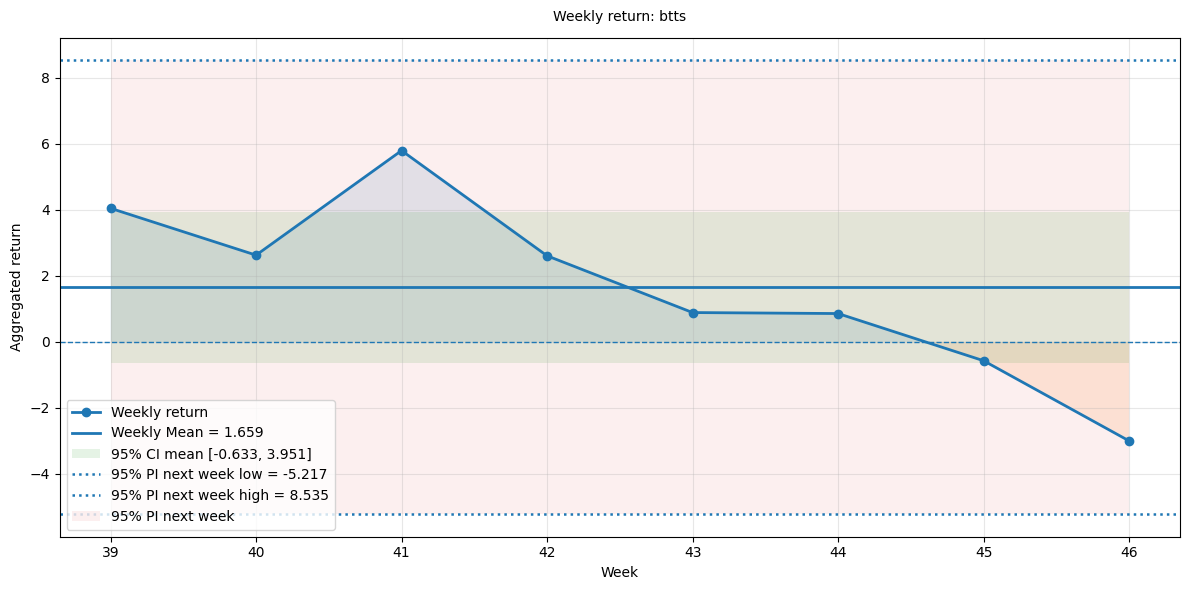

In [24]:
sys.path.append("../..")
from strategies.utils import analyze_strategies, get_best_strategies

df_tot_filtered = pd.concat([df_train_filtered, df_test_filtered], axis=0).reset_index(drop=True).rename(columns={target_col: "result", "time": "date"})
df_tot_filtered = df_tot_filtered.sort_values(by="date", ascending=False)
 
df_tot_filtered["strategy"] = target_col

weekly_return, stats = analyze_strategies(df_tot_filtered, strategies=[target_col], print_pi=True)

In [25]:
weeks = stats["n_weeks"]
total_weeks = max(df["weeks"])

print(f"No. of weeks covered: {weeks}/{total_weeks} ({np.round((weeks/total_weeks), 2)})")

No. of weeks covered: 8/46 (0.17)


In [47]:
get_best_strategies(df_tot_filtered)

,weekly_mean_return,weekly_std_return,weekly_counts,weekly_std_counts,total_counts,accuracy
btts,0.52,0.92,1.64,1.80,74,0.74
